# **Video Frame Prediction using ConvLSTM (Spatio-Temporal Video Intelligence System)**

### **Project Objective**

The objective of this project is to develop a **Video Frame Prediction System** using **Convolutional LSTM (ConvLSTM) Networks** to predict future frames in a video sequence based on past frames.

Video prediction is a complex problem that requires modeling both spatial and temporal dependencies. This project focuses on leveraging deep learning techniques to understand motion patterns and generate future frames.

The system is designed to:

- Predict **future video frames from past sequences**  
- Capture **spatial features using convolutional layers**  
- Learn **temporal dependencies using LSTM-based architecture**  
- Demonstrate the effectiveness of **ConvLSTM for spatio-temporal modeling**  

This project is highly applicable in:
- video analytics  
- autonomous driving systems  
- weather forecasting  
- surveillance systems  

### **Dataset Used**

This project utilizes video datasets consisting of sequences of frames.

### **Dataset Sources**

- Video Frame Datasets *(e.g., Moving MNIST, real-world video datasets, or dataset used in your notebook)*  

### **Dataset Characteristics**

The dataset includes:

- **Input sequences**:
  - consecutive video frames  

- **Target output**:
  - future frames to be predicted  

Key characteristics:
- spatio-temporal data  
- high-dimensional image sequences  
- sequential frame dependencies  

### **How Dataset is Used in the Project**

The dataset is processed through a video prediction pipeline:

- **Data preprocessing**
  - frame normalization  
  - resizing frames  

- **Sequence preparation**
  - creating input-output frame sequences  

- **Train-test split**
  - ensures evaluation  

- **Model training**
  - ConvLSTM learns spatial + temporal patterns  
  - predicts future frames  

The dataset enables the model to learn **motion dynamics and spatial structures**, which are essential for video prediction.




### **Import Core Libraries:**

In [1]:
import os
import json
import random
import re
import warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

try:
    import tensorflow as tf
except ImportError:
    raise ImportError("TensorFlow is not installed. Please run: pip install tensorflow")

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

### **Reproducibility Setup:**

In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
print("Seed fixed at:", SEED)

Seed fixed at: 42


### **Create Project Folders:**

In [3]:
BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / "data_convlstm_video"
ARTIFACT_DIR = BASE_DIR / "artifacts_convlstm_video"
MODEL_DIR = ARTIFACT_DIR / "models"
PLOT_DIR = ARTIFACT_DIR / "plots"
for folder in [DATA_DIR, ARTIFACT_DIR, MODEL_DIR, PLOT_DIR]:
    folder.mkdir(parents=True, exist_ok=True)
print(DATA_DIR)
print(ARTIFACT_DIR)

C:\Users\atripathi\OneDrive - Veralto\Desktop\AI Codes\RNN\LSTM Model\Video Frame Prediction using Convolutional LSTM\data_convlstm_video
C:\Users\atripathi\OneDrive - Veralto\Desktop\AI Codes\RNN\LSTM Model\Video Frame Prediction using Convolutional LSTM\artifacts_convlstm_video


### **Generate Moving-Object Video Dataset:**

In [4]:
def generate_moving_sequences(n_samples=2500, seq_len=6, image_size=32, obj_size=5, seed=42):
    rng = np.random.default_rng(seed)
    X, y = [], []
    for _ in range(n_samples):
        frames = np.zeros((seq_len + 1, image_size, image_size), dtype="float32")
        x = rng.integers(0, image_size - obj_size)
        y0 = rng.integers(0, image_size - obj_size)
        vx = rng.choice([-1, 1]) * rng.integers(1, 3)
        vy = rng.choice([-1, 1]) * rng.integers(1, 3)

        for t in range(seq_len + 1):
            frames[t, y0:y0+obj_size, x:x+obj_size] = 1.0
            x += vx
            y0 += vy
            if x < 0 or x > image_size - obj_size:
                vx *= -1
                x = np.clip(x, 0, image_size - obj_size)
            if y0 < 0 or y0 > image_size - obj_size:
                vy *= -1
                y0 = np.clip(y0, 0, image_size - obj_size)

        X.append(frames[:seq_len, ..., None])
        y.append(frames[seq_len, ..., None])
    return np.array(X), np.array(y)

X_all, y_all = generate_moving_sequences(n_samples=2500, seq_len=6, seed=SEED)
print(X_all.shape, y_all.shape)

(2500, 6, 32, 32, 1) (2500, 32, 32, 1)


### **Train / Validation / Test Split:**

In [5]:
X_train, X_temp, y_train, y_temp = train_test_split(X_all, y_all, test_size=0.30, random_state=SEED)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=SEED)
print(X_train.shape, X_val.shape, X_test.shape)

(1750, 6, 32, 32, 1) (375, 6, 32, 32, 1) (375, 6, 32, 32, 1)


### **Dataset Summary:**

In [6]:
print("Train sequences:", len(X_train))
print("Validation sequences:", len(X_val))
print("Test sequences:", len(X_test))
print("Input shape:", X_train.shape[1:])
print("Target shape:", y_train.shape[1:])

Train sequences: 1750
Validation sequences: 375
Test sequences: 375
Input shape: (6, 32, 32, 1)
Target shape: (32, 32, 1)


### **Visualize Input Sequence Example:**

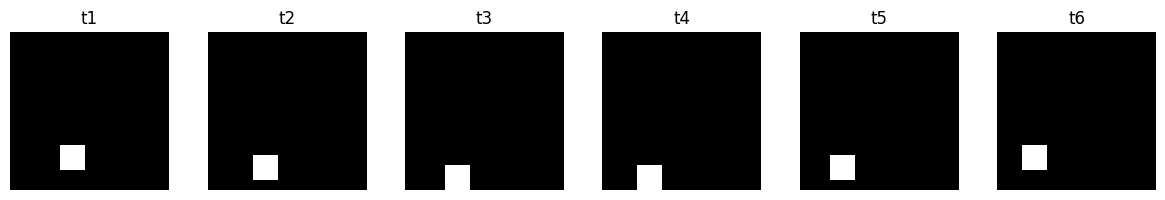

In [7]:
plt.figure(figsize=(12, 2))
for t in range(X_train.shape[1]):
    ax = plt.subplot(1, X_train.shape[1], t + 1)
    plt.imshow(X_train[0, t].squeeze(), cmap="gray")
    plt.axis("off")
    ax.set_title(f"t{t+1}")
plt.tight_layout()
plt.show()

### **Visualize Target Next Frame:**

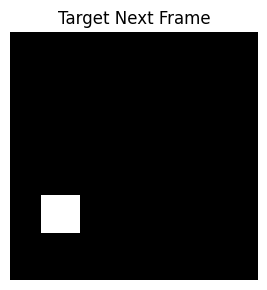

In [8]:
plt.figure(figsize=(3, 3))
plt.imshow(y_train[0].squeeze(), cmap="gray")
plt.axis("off")
plt.title("Target Next Frame")
plt.tight_layout()
plt.show()

### **Pixel Intensity Diagnostics:**

In [9]:
print("Train mean:", round(float(X_train.mean()), 4))
print("Target mean:", round(float(y_train.mean()), 4))

Train mean: 0.0244
Target mean: 0.0244


### **Motion Area Per Frame:**

In [10]:
motion_profile = X_train[0].reshape(X_train.shape[1], -1).sum(axis=1)
motion_profile

array([25., 25., 25., 25., 25., 25.], dtype=float32)

### **Plot Motion Area Per Frame:**

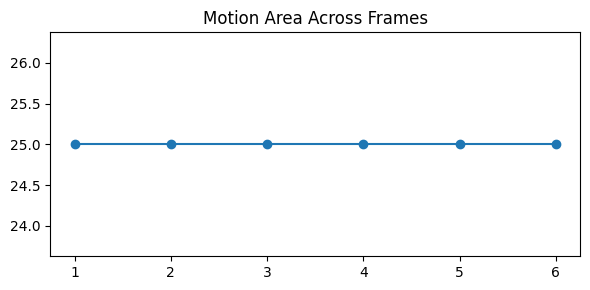

In [11]:
plt.figure(figsize=(6, 3))
plt.plot(range(1, len(motion_profile)+1), motion_profile, marker="o")
plt.title("Motion Area Across Frames")
plt.tight_layout()
plt.show()

### **Build Baseline Predictions:**`

In [12]:
baseline_val_pred = X_val[:, -1]
baseline_test_pred = X_test[:, -1]
print(baseline_val_pred.shape, baseline_test_pred.shape)

(375, 32, 32, 1) (375, 32, 32, 1)


### **Define Frame Metrics:**

In [13]:
def frame_mae(y_true, y_pred):
    return float(np.mean(np.abs(y_true - y_pred)))
def frame_rmse(y_true, y_pred):
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))

### **Baseline Metrics:**

In [14]:
baseline_val_mae = frame_mae(y_val, baseline_val_pred)
baseline_val_rmse = frame_rmse(y_val, baseline_val_pred)
baseline_test_mae = frame_mae(y_test, baseline_test_pred)
baseline_test_rmse = frame_rmse(y_test, baseline_test_pred)
print(baseline_val_mae, baseline_val_rmse, baseline_test_mae, baseline_test_rmse)

0.02423437498509884 0.15567393600940704 0.023895833641290665 0.15458276867866516


### **Build ConvLSTM Model:**

In [15]:
def build_convlstm(input_shape):
    inputs = tf.keras.Input(shape=input_shape)
    x = tf.keras.layers.ConvLSTM2D(32, (3, 3), padding="same", return_sequences=True, activation="tanh")(inputs)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.ConvLSTM2D(32, (3, 3), padding="same", return_sequences=False, activation="tanh")(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Conv2D(16, (3, 3), activation="relu", padding="same")(x)
    outputs = tf.keras.layers.Conv2D(1, (3, 3), activation="sigmoid", padding="same")(x)

    model = tf.keras.Model(inputs, outputs)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss="mse",
        metrics=[tf.keras.metrics.MeanAbsoluteError(name="mae")]
    )
    return model

### **Instantiate ConvLSTM Model:**

In [16]:
convlstm_model = build_convlstm(input_shape=X_train.shape[1:])
convlstm_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 6, 32, 32, 1)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_lstm2d (ConvLSTM2D)             │ (None, 6, 32, 32, 32)       │          38,144 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 6, 32, 32, 32)       │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_lstm2d_1 (ConvLSTM2D)           │ (None, 32, 32, 32)          │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 32, 32, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 32, 32, 16)          │           4,624 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 32, 32, 1)           │             145 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 117,025 (457.13 KB)

 Trainable params: 116,897 (456.63 KB)

 Non-trainable params: 128 (512.00 B)

### **Training Callbacks:**

In [17]:
callbacks = [
    EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6)
]

### **Train ConvLSTM:**

In [18]:
history = convlstm_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=15,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/15
55/55 ━━━━━━━━━━━━━━━━━━━━ 10s 148ms/step - loss: 0.0651 - mae: 0.1618 - val_loss: 0.1871 - val_mae: 0.4265 - learning_rate: 0.0010
Epoch 2/15
55/55 ━━━━━━━━━━━━━━━━━━━━ 8s 140ms/step - loss: 0.0099 - mae: 0.0373 - val_loss: 0.1561 - val_mae: 0.3839 - learning_rate: 0.0010
Epoch 3/15
55/55 ━━━━━━━━━━━━━━━━━━━━ 8s 145ms/step - loss: 0.0058 - mae: 0.0272 - val_loss: 0.1266 - val_mae: 0.3378 - learning_rate: 0.0010
Epoch 4/15
55/55 ━━━━━━━━━━━━━━━━━━━━ 8s 140ms/step - loss: 0.0041 - mae: 0.0200 - val_loss: 0.1055 - val_mae: 0.2994 - learning_rate: 0.0010
Epoch 5/15
55/55 ━━━━━━━━━━━━━━━━━━━━ 8s 143ms/step - loss: 0.0033 - mae: 0.0162 - val_loss: 0.0947 - val_mae: 0.2758 - learning_rate: 0.0010
Epoch 6/15
55/55 ━━━━━━━━━━━━━━━━━━━━ 8s 141ms/step - loss: 0.0029 - mae: 0.0138 - val_loss: 0.0905 - val_mae: 0.2639 - learning_rate: 0.0010
Epoch 7/15
55/55 ━━━━━━━━━━━━━━━━━━━━ 8s 139ms/step - loss: 0.0026 - mae: 0.0122 - val_loss: 0.0844 - val_mae: 0.2498 - learning_rate: 0.0010
Epoch

### **Plot Training vs Validation Loss:**

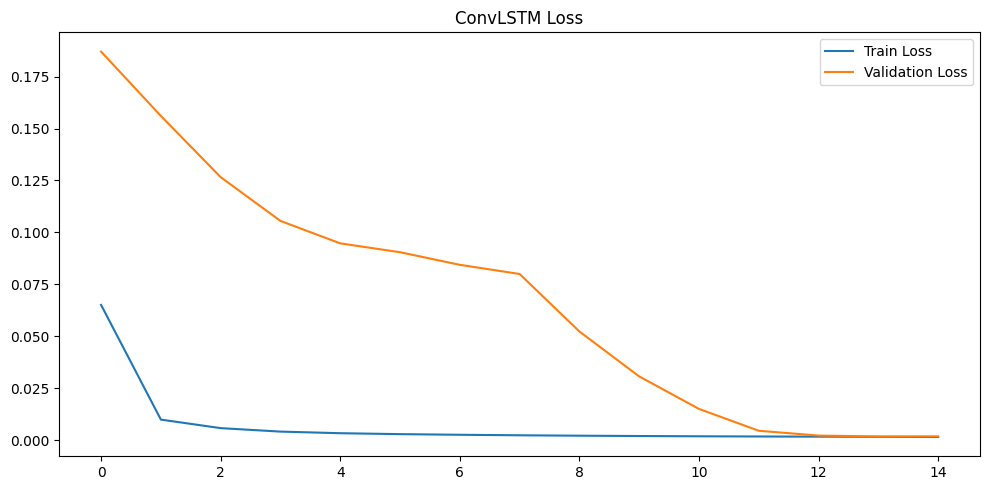

In [19]:
history_df = pd.DataFrame(history.history)
plt.figure(figsize=(10, 5))
plt.plot(history_df["loss"], label="Train Loss")
plt.plot(history_df["val_loss"], label="Validation Loss")
plt.title("ConvLSTM Loss")
plt.legend()
plt.tight_layout()
plt.show()

### **Plot Training vs Validation MAE:**

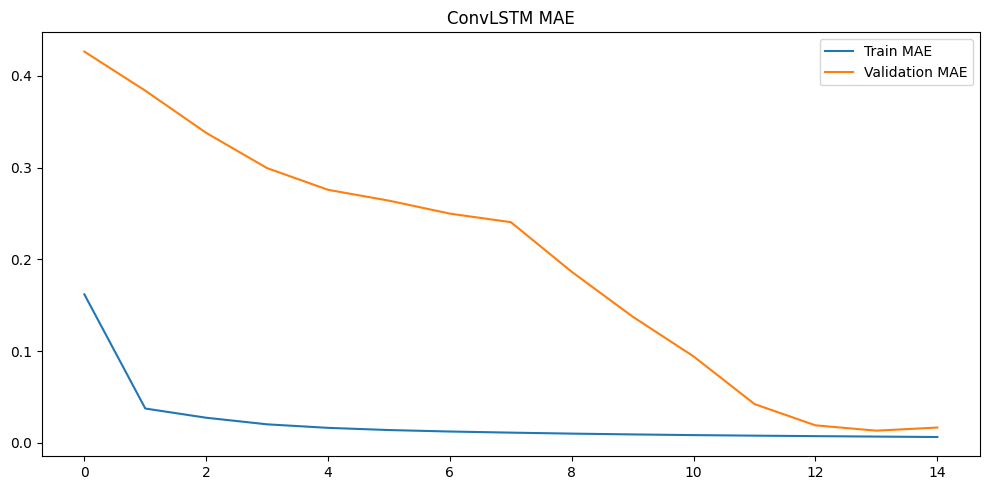

In [20]:
plt.figure(figsize=(10, 5))
plt.plot(history_df["mae"], label="Train MAE")
plt.plot(history_df["val_mae"], label="Validation MAE")
plt.title("ConvLSTM MAE")
plt.legend()
plt.tight_layout()
plt.show()

### **Predict Validation and Test Frames:**

In [21]:
val_pred = convlstm_model.predict(X_val, verbose=0)
test_pred = convlstm_model.predict(X_test, verbose=0)
print(val_pred.shape, test_pred.shape)

(375, 32, 32, 1) (375, 32, 32, 1)


### **Validation Metrics:**

In [22]:
val_mae = frame_mae(y_val, val_pred)
val_rmse = frame_rmse(y_val, val_pred)
print(val_mae, val_rmse)

0.013140738010406494 0.04158243164420128


### **Test Metrics:**

In [23]:
test_mae = frame_mae(y_test, test_pred)
test_rmse = frame_rmse(y_test, test_pred)
print(test_mae, test_rmse)

0.013382806442677975 0.04495716467499733


### **Compare Baseline vs ConvLSTM:**

In [24]:
comparison_df = pd.DataFrame({
    "Model": ["Persistence Baseline", "ConvLSTM"],
    "Validation_MAE": [baseline_val_mae, val_mae],
    "Validation_RMSE": [baseline_val_rmse, val_rmse],
    "Test_MAE": [baseline_test_mae, test_mae],
    "Test_RMSE": [baseline_test_rmse, test_rmse]
})
comparison_df

,Model,Validation_MAE,Validation_RMSE,Test_MAE,Test_RMSE
0,Persistence Baseline,0.024234,0.155674,0.023896,0.154583
1,ConvLSTM,0.013141,0.041582,0.013383,0.044957


### **Residual Frame Diagnostics:**

In [25]:
residual_map = y_test - test_pred
print("Residual mean:", float(residual_map.mean()))
print("Residual std:", float(residual_map.std()))

Residual mean: -0.008959438651800156
Residual std: 0.04405536502599716


### **Plot Residual Histogram:**

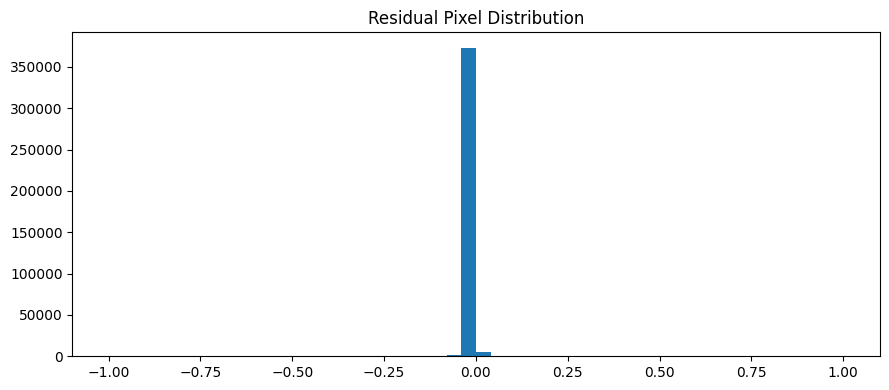

In [26]:
plt.figure(figsize=(9, 4))
plt.hist(residual_map.flatten(), bins=50)
plt.title("Residual Pixel Distribution")
plt.tight_layout()
plt.show()

### **Sample Prediction Visualization:**

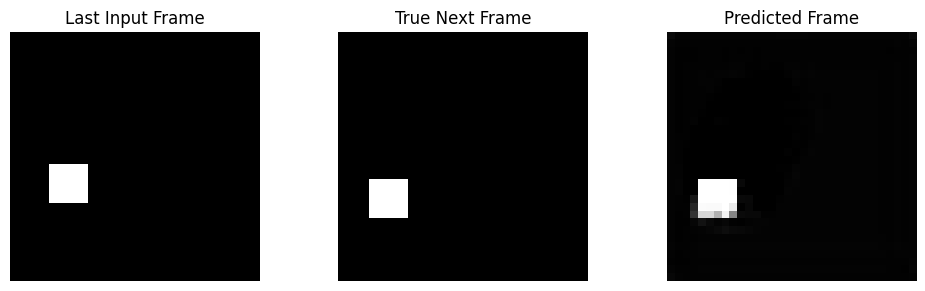

In [27]:
idx = 0
plt.figure(figsize=(10, 3))
ax = plt.subplot(1, 3, 1)
plt.imshow(X_test[idx, -1].squeeze(), cmap="gray")
plt.axis("off")
ax.set_title("Last Input Frame")
ax = plt.subplot(1, 3, 2)
plt.imshow(y_test[idx].squeeze(), cmap="gray")
plt.axis("off")
ax.set_title("True Next Frame")
ax = plt.subplot(1, 3, 3)
plt.imshow(test_pred[idx].squeeze(), cmap="gray")
plt.axis("off")
ax.set_title("Predicted Frame")
plt.tight_layout()
plt.show()

### **Visualize Multiple Test Predictions:**

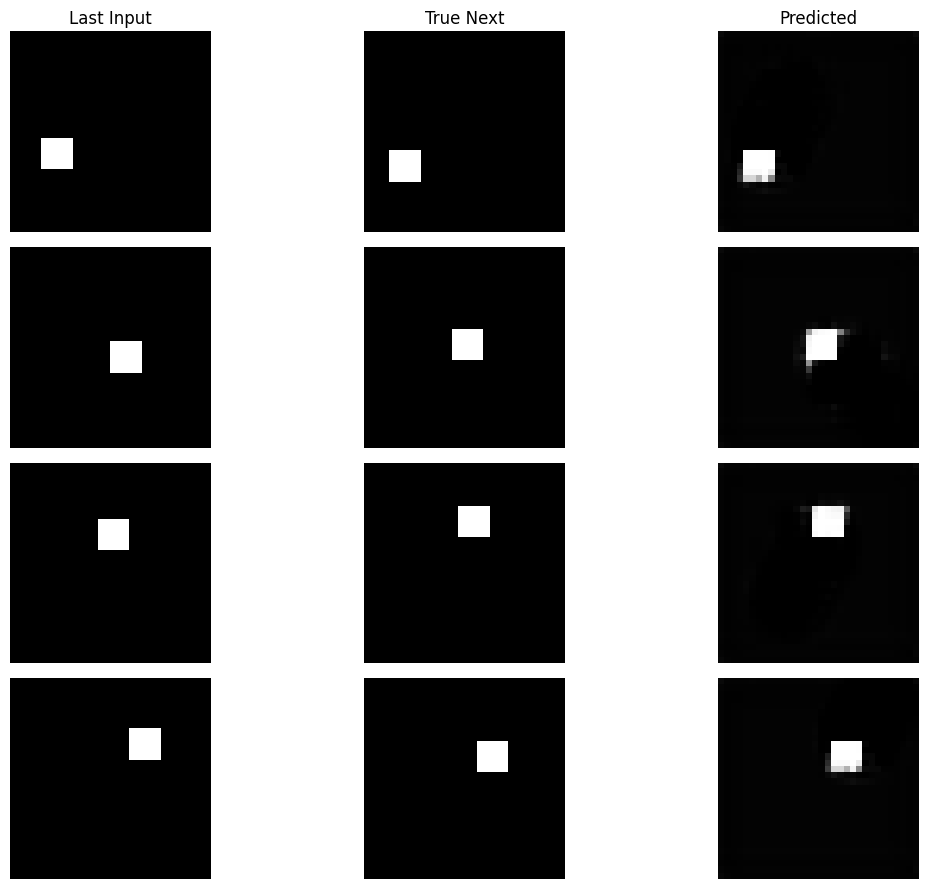

In [28]:
plt.figure(figsize=(12, 9))
for i in range(4):
    ax = plt.subplot(4, 3, 3*i+1)
    plt.imshow(X_test[i, -1].squeeze(), cmap="gray")
    plt.axis("off")
    if i == 0: ax.set_title("Last Input")
    ax = plt.subplot(4, 3, 3*i+2)
    plt.imshow(y_test[i].squeeze(), cmap="gray")
    plt.axis("off")
    if i == 0: ax.set_title("True Next")
    ax = plt.subplot(4, 3, 3*i+3)
    plt.imshow(test_pred[i].squeeze(), cmap="gray")
    plt.axis("off")
    if i == 0: ax.set_title("Predicted")
plt.tight_layout()
plt.show()

### **Thresholded Frame Comparison:**

In [29]:
threshold = 0.5
binary_pred = (test_pred >= threshold).astype("float32")
binary_true = (y_test >= threshold).astype("float32")
print(binary_pred.shape)

(375, 32, 32, 1)


### **Pixel Accuracy After Thresholding:**

In [30]:
pixel_acc = float((binary_pred == binary_true).mean())
print(pixel_acc)

0.9978958333333333


### **IoU Helper:**

In [31]:
def frame_iou(y_true, y_pred, smooth=1e-6):
    yt = y_true.reshape(len(y_true), -1)
    yp = y_pred.reshape(len(y_pred), -1)
    inter = (yt * yp).sum(axis=1)
    union = yt.sum(axis=1) + yp.sum(axis=1) - inter
    return float(np.mean((inter + smooth) / (union + smooth)))

### **IoU on Thresholded Frames:**

In [32]:
test_iou = frame_iou(binary_true, binary_pred)
baseline_iou = frame_iou((y_test >= 0.5).astype("float32"), (baseline_test_pred >= 0.5).astype("float32"))
print(baseline_iou, test_iou)

0.35077157616615295 0.9195999503135681


### **Best Prediction Examples:**

In [33]:
sample_errors = np.mean(np.abs(y_test - test_pred), axis=(1,2,3))
best_idx = np.argsort(sample_errors)[:8]
best_idx

array([231,  71, 205, 180, 197, 334, 182, 326], dtype=int64)

### **Worst Prediction Examples:**

In [34]:
worst_idx = np.argsort(sample_errors)[-8:]
worst_idx

array([233, 137, 257,  33, 266, 234, 274, 313], dtype=int64)

### **Visualize Best Predictions:**

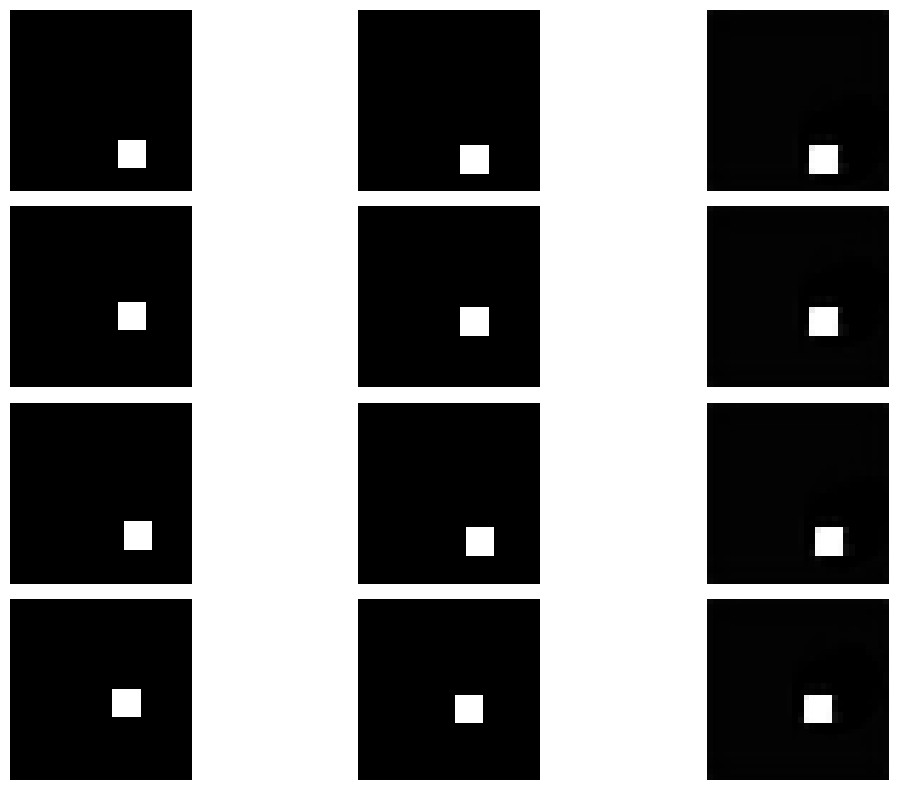

In [35]:
plt.figure(figsize=(12, 8))
for i, idx in enumerate(best_idx[:4]):
    ax = plt.subplot(4, 3, 3*i+1)
    plt.imshow(X_test[idx, -1].squeeze(), cmap="gray")
    plt.axis("off")
    ax = plt.subplot(4, 3, 3*i+2)
    plt.imshow(y_test[idx].squeeze(), cmap="gray")
    plt.axis("off")
    ax = plt.subplot(4, 3, 3*i+3)
    plt.imshow(test_pred[idx].squeeze(), cmap="gray")
    plt.axis("off")
plt.tight_layout()
plt.show()

### **Visualize Worst Predictions:**

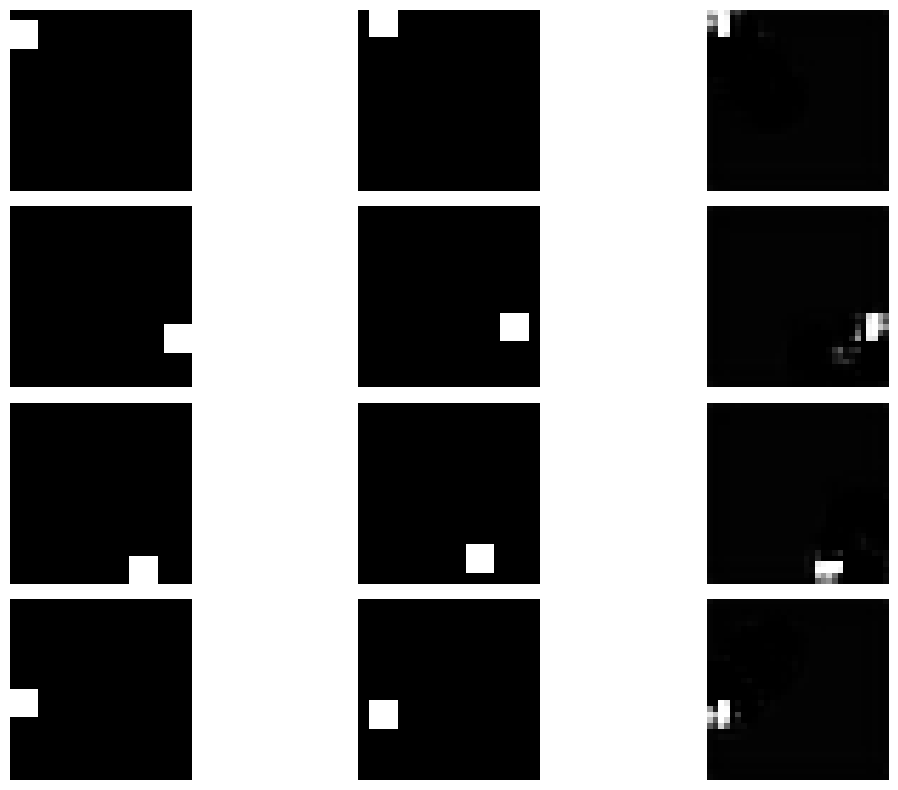

In [36]:
plt.figure(figsize=(12, 8))
for i, idx in enumerate(worst_idx[:4]):
    ax = plt.subplot(4, 3, 3*i+1)
    plt.imshow(X_test[idx, -1].squeeze(), cmap="gray")
    plt.axis("off")
    ax = plt.subplot(4, 3, 3*i+2)
    plt.imshow(y_test[idx].squeeze(), cmap="gray")
    plt.axis("off")
    ax = plt.subplot(4, 3, 3*i+3)
    plt.imshow(test_pred[idx].squeeze(), cmap="gray")
    plt.axis("off")
plt.tight_layout()
plt.show()

### **Motion Intensity Comparison:**

In [37]:
true_motion = y_test.reshape(len(y_test), -1).sum(axis=1)
pred_motion = test_pred.reshape(len(test_pred), -1).sum(axis=1)
motion_df = pd.DataFrame({"true_motion": true_motion, "pred_motion": pred_motion})
motion_df.describe()

,true_motion,pred_motion
count,375.0,375.000000
mean,25.0,34.174465
std,0.0,3.511431
min,25.0,19.481709
25%,25.0,34.458004
50%,25.0,35.206474
75%,25.0,35.666695
max,25.0,43.136642


### **Plot Predicted vs True Motion:**

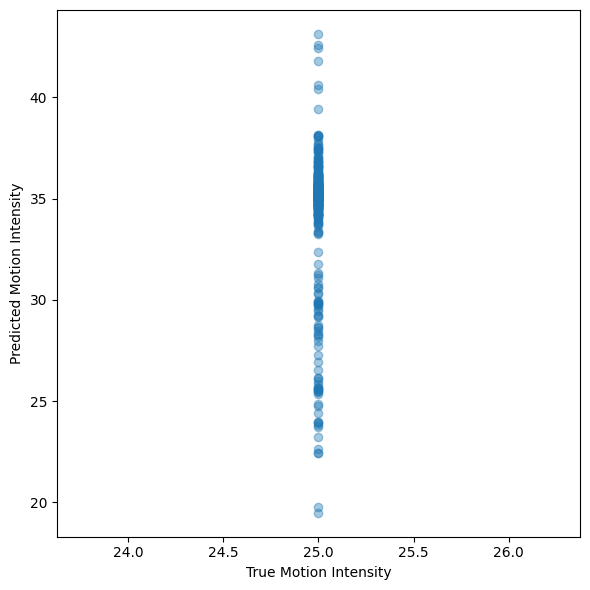

In [38]:
plt.figure(figsize=(6, 6))
plt.scatter(motion_df["true_motion"], motion_df["pred_motion"], alpha=0.4)
plt.xlabel("True Motion Intensity")
plt.ylabel("Predicted Motion Intensity")
plt.tight_layout()
plt.show()

### **Error by Motion Intensity:**

In [39]:
motion_error_df = pd.DataFrame({
    "motion_level": pd.cut(true_motion, bins=4),
    "abs_error": sample_errors
})
motion_error_df.groupby("motion_level")["abs_error"].mean()

motion_level
(24.988, 25.0]    0.013383
Name: abs_error, dtype: float32

### **Frame Difference Visualization:**

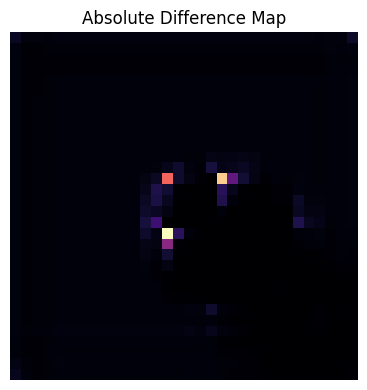

In [40]:
idx = 1
diff_map = np.abs(y_test[idx].squeeze() - test_pred[idx].squeeze())
plt.figure(figsize=(4, 4))
plt.imshow(diff_map, cmap="magma")
plt.axis("off")
plt.title("Absolute Difference Map")
plt.tight_layout()
plt.show()

### **Save Model Artifacts:**

In [41]:
model_path = MODEL_DIR / "convlstm_video_prediction.keras"
meta_path = MODEL_DIR / "video_meta.json"

convlstm_model.save(model_path)

meta = {
    "input_frames": int(X_train.shape[1]),
    "height": int(X_train.shape[2]),
    "width": int(X_train.shape[3]),
    "channels": int(X_train.shape[4]),
    "seed": SEED
}
with open(meta_path, "w") as f:
    json.dump(meta, f, indent=4)

print(model_path)
print(meta_path)

C:\Users\atripathi\OneDrive - Veralto\Desktop\AI Codes\RNN\LSTM Model\Video Frame Prediction using Convolutional LSTM\artifacts_convlstm_video\models\convlstm_video_prediction.keras
C:\Users\atripathi\OneDrive - Veralto\Desktop\AI Codes\RNN\LSTM Model\Video Frame Prediction using Convolutional LSTM\artifacts_convlstm_video\models\video_meta.json


### **Reload Model for Sanity Check:**

In [42]:
reloaded_model = tf.keras.models.load_model(model_path)
sanity_pred = reloaded_model.predict(X_test[:2], verbose=0)
sanity_pred.shape

(2, 32, 32, 1)

### **Final Metrics Summary Table:**

In [43]:
summary_table = pd.DataFrame({
    "Metric": ["Baseline Test MAE", "Baseline Test RMSE", "ConvLSTM Test MAE", "ConvLSTM Test RMSE", "ConvLSTM IoU", "Pixel Accuracy"],
    "Value": [baseline_test_mae, baseline_test_rmse, test_mae, test_rmse, test_iou, pixel_acc]
})
summary_table

,Metric,Value
0,Baseline Test MAE,0.023896
1,Baseline Test RMSE,0.154583
2,ConvLSTM Test MAE,0.013383
3,ConvLSTM Test RMSE,0.044957
4,ConvLSTM IoU,0.919600
5,Pixel Accuracy,0.997896


### **Project Summary**

This project presents a complete implementation of a **Video Frame Prediction System using ConvLSTM Networks**, focusing on predicting future frames in video sequences.

The workflow begins with preprocessing video data, including frame normalization and sequence preparation.

The core of the system is a **ConvLSTM Model**, which consists of:

### **1. Input Layer**

- Accepts sequences of video frames  

### **2. ConvLSTM Layers**

- Combine convolution and LSTM operations  
- Capture spatial and temporal dependencies  

### **3. Output Layer**

- Generates predicted future frames  

The model learns:
- motion patterns  
- spatial structures  
- temporal evolution of scenes  

A key strength of this project is:

- **Spatio-temporal modeling**
  - integrates vision and sequence learning  

- **Generative capability**
  - predicts unseen future frames  

Evaluation is performed using:

- Mean Squared Error (MSE)  
- visual inspection of predicted frames  

The system can be used in real-world applications to:

- predict future video frames  
- analyze motion patterns  
- enhance video-based AI systems  

Overall, this project demonstrates advanced AI capabilities and showcases the ability to build **spatio-temporal video intelligence systems using deep learning**.

### **Key Highlights**

- Built a **Video Frame Prediction system using ConvLSTM**, targeting computer vision and sequence modeling applications.

- Addressed complex problem:
  - predicting future frames in video sequences  

- Utilized dataset with:
  - spatio-temporal video data  

- Implemented a complete **data preprocessing pipeline**, including:
  - frame normalization  
  - sequence preparation  

- Leveraged **ConvLSTM architecture**, enabling:
  - combined spatial and temporal modeling  

- Designed a **prediction system**, enabling:
  - generation of future frames  

- Developed a **video intelligence model**, capable of:
  - capturing motion dynamics  
  - predicting temporal evolution  

- Evaluated model performance using:
  - MSE  
  - qualitative visualization  

- Enabled **real-world applications**, including:
  - surveillance systems  
  - autonomous driving  
  - weather forecasting  

- Designed for **deployment scenarios**, including:
  - video analytics platforms  
  - AI-powered vision systems  

- Demonstrates strong expertise in:
  - **computer vision**  
  - **deep learning (ConvLSTM)**  
  - **spatio-temporal modeling**